### Importing Data from 2022 and 2023

In [36]:
import pandas as pd

In [148]:
# Importing the FW22 data with the uda information

weekly_data_fw22 = pd.read_csv('FW22WeeklyPastData.csv',dtype={'ItemCode':object})

In [150]:
#order columns
weekly_data_fw22 = weekly_data_fw22.groupby("ItemCode",as_index=False).apply(lambda x: x.sort_values("WeekStartDate",ascending=True))

In [151]:
# Lag Discount Rate
weekly_data_fw22['DiscountRateLag'] = weekly_data_fw22.groupby('ItemCode',as_index=False)['DiscountRateOnPrice'].shift(1)

In [155]:
weekly_data_fw22.reset_index(drop=True,inplace=True)

In [158]:
data = pd.read_csv("WeeklyPastData.csv",dtype={'ItemCode':object})

In [159]:
data_2022 = pd.read_csv("Data2022.csv",dtype={'ItemCode':object})

In [160]:
data = data.drop("PrevWeekStock",axis=1)

In [161]:
data_2022.dtypes

H1                   object
H2                   object
H3                   object
H4                   object
H5                   object
ItemCode             object
WeekStartDate        object
Sales                 int64
Stock                 int64
Price               float64
FirstPrice          float64
Discount            float64
DiscountOnPrice     float64
PrevDiscountRate    float64
PrevSales             int64
dtype: object

In [162]:
data_merged = pd.concat([data,data_2022]).reset_index(drop=True)

In [163]:
import matplotlib.pyplot as plt

In [164]:
data2 = data_merged[data_merged.Sales>0]

In [165]:
data2 = data2[data2.PrevSales>0]

In [166]:
data2["Fraction"] = data2.Sales/data2.PrevSales

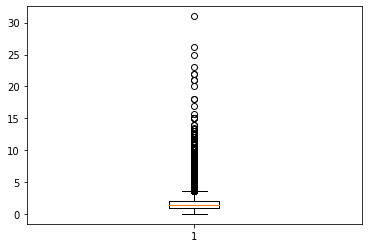

In [167]:
plt.boxplot(data2["Fraction"])
plt.show()

In [168]:
data2[data2.Fraction>10]

,H1,H2,H3,H4,H5,ItemCode,WeekStartDate,Sales,Stock,Price,FirstPrice,Discount,DiscountOnPrice,PrevDiscountRate,PrevSales,Fraction
164,AYAKKABI,KADIN,CASUAL,BOT,BASIC GUNLUK BOT,000000000101486211,2023-11-09,27,916,1203.6944,1574.0648,0.239600,0.235296,0.000000,2,13.500000
372,AYAKKABI,COCUK,NaN,BOT,OUTDOOR HI,000000000101181021,2023-11-09,299,1021,305.5463,694.4352,0.572700,0.560007,0.000000,26,11.500000
904,AYAKKABI,AKTIFCOCUK,ATHLETIC,AYAKKABI,KOSU-YURUYUS,000000000101120117,2023-11-09,12,131,1111.0185,1342.5000,0.207500,0.172426,0.000000,1,12.000000
931,AYAKKABI,AKTIFSPOR,LEISURE,AYAKKABI,SNEAKER,000000000101318109,2023-11-09,107,881,833.3241,1018.5093,0.474800,0.181820,0.000000,8,13.375000
1003,AYAKKABI,AKTIFSPOR,LEISURE,AYAKKABI,SNEAKER,000000000101327926,2023-11-23,11,155,509.2500,861.1019,0.443600,0.408607,0.139786,1,11.000000
1269,AYAKKABI,AKTIFSPOR,ATHLETIC,AYAKKABI,SPORT COMFORT,000000000101382783,2023-10-26,33,970,462.9537,648.1389,0.312900,0.285718,0.000000,3,11.000000
1957,AYAKKABI,AKTIFSPOR,LEISURE,AYAKKABI,SNEAKER,000000000101118307,2023-11-09,25,86,1388.7963,1759.1667,0.348300,0.210537,0.000000,2,12.500000
2545,AYAKKABI,AKTIFSPOR,ATHLETIC,AYAKKABI,KOSU,000000000101476592,2023-11-09,12,464,1620.2778,1944.3519,0.257700,0.166675,0.000000,1,12.000000
2561,AYAKKABI,ERKEK,CASUAL,AYAKKABI,HAVUZ TABAN SNEAKER,000000000101477757,2023-10-26,23,284,1620.3611,2314.8056,0.313100,0.300001,0.000000,2,11.500000
2867,AYAKKABI,KADIN,CASUAL,BOT,WORKER BOT,000000000101468690,2023-11-09,46,384,1388.8796,1666.6574,0.189400,0.166668,0.000000,2,23.000000


In [169]:
lower_limit = data2["Fraction"].quantile(0.1)
upper_limit = data2["Fraction"].quantile(0.9)

data3 = data2[(data2["Fraction"]>lower_limit)&(data2["Fraction"]<upper_limit)]

In [170]:
data3

,H1,H2,H3,H4,H5,ItemCode,WeekStartDate,Sales,Stock,Price,FirstPrice,Discount,DiscountOnPrice,PrevDiscountRate,PrevSales,Fraction
2,AYAKKABI,KADIN,CASUAL,BOT,WORKER BOT,000000000101207210,2023-10-26,15,1108,509.2500,648.1389,0.234300,0.214289,0.000000,11,1.363636
3,AYAKKABI,KADIN,CASUAL,BOT,WORKER BOT,000000000101207210,2023-11-09,48,1040,416.6574,648.1389,0.431000,0.357148,0.214289,20,2.400000
4,AYAKKABI,KADIN,DRESS,BOT,DUZ BOT,000000000101207314,2023-10-26,8,379,740.7315,925.9167,0.261700,0.200002,0.000000,4,2.000000
5,AYAKKABI,AKTIFCOCUK,OUTDOOR,BOT,OUTDOOR HI,000000000101207856,2023-10-26,7,927,537.0278,629.6204,0.226300,0.147061,0.000000,11,0.636364
6,AYAKKABI,AKTIFCOCUK,OUTDOOR,BOT,OUTDOOR HI,000000000101207856,2023-11-23,13,862,444.4352,629.6204,0.338900,0.294122,0.147061,18,0.722222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13902,AYAKKABI,ERKEK,COMFORT,TERLIK,EV ICI TERLIK,000000000101206961,2022-11-24,39,1529,79.9900,99.9900,0.185817,0.194867,0.000000,40,0.975000
13903,AYAKKABI,KADIN,CASUAL,BOT,CHELSEA BOT,000000000101208125,2023-02-02,5,18,699.0000,799.0000,0.339936,0.125156,0.000000,2,2.500000
13905,AYAKKABI,KADIN,CASUAL,BOT,CHELSEA BOT,000000000101382104,2023-01-19,23,759,499.9900,599.9900,0.152712,0.166669,0.000000,18,1.277778
13906,AYAKKABI,ERKEK,DRESS,BOT,INFORMAL BOT,000000000101208458,2023-01-19,59,1666,579.9900,649.9900,0.119311,0.101946,0.000000,46,1.282609


In [171]:
import numpy as np

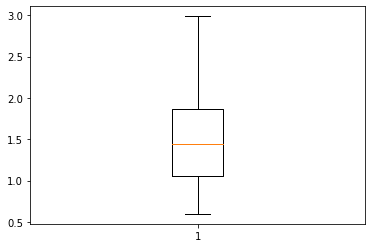

In [172]:
plt.boxplot(data3.Fraction)
plt.show()

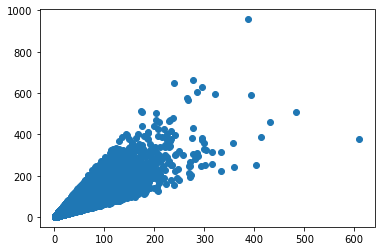

In [173]:
plt.scatter(data3["PrevSales"],data3["Sales"])
plt.show()

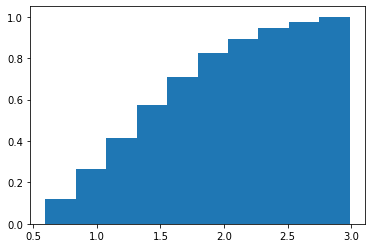

In [174]:
plt.hist(data3["Fraction"],bins=10,density=True,cumulative=True)
plt.show()

In [175]:
data3.dtypes

H1                   object
H2                   object
H3                   object
H4                   object
H5                   object
ItemCode             object
WeekStartDate        object
Sales                 int64
Stock                 int64
Price               float64
FirstPrice          float64
Discount            float64
DiscountOnPrice     float64
PrevDiscountRate    float64
PrevSales             int64
Fraction            float64
dtype: object

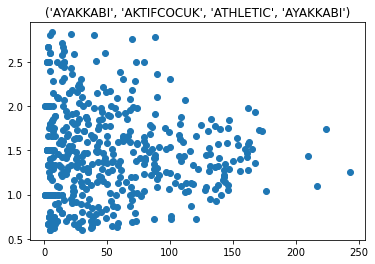

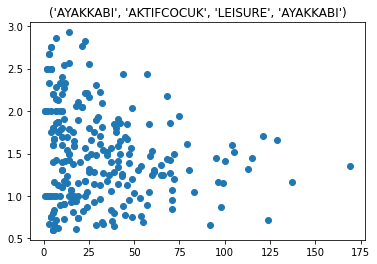

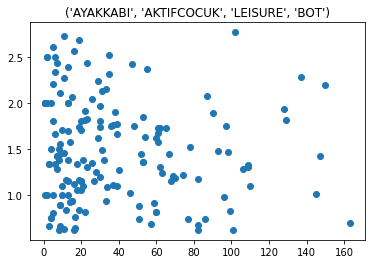

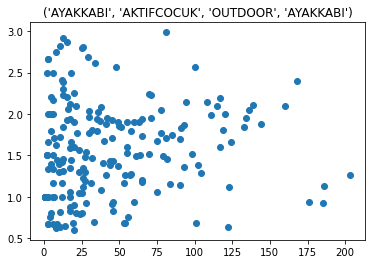

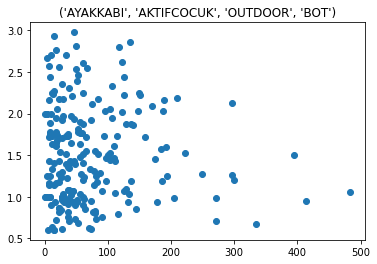

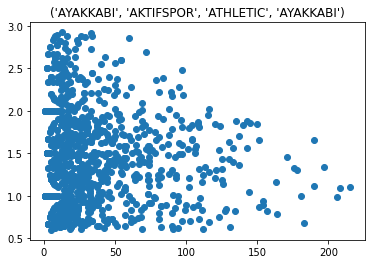

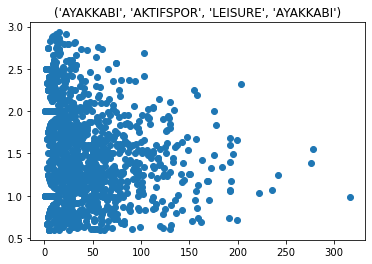

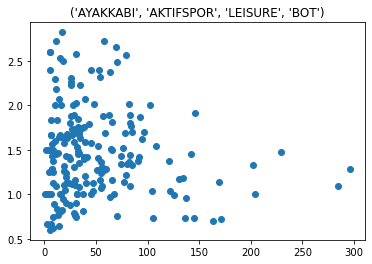

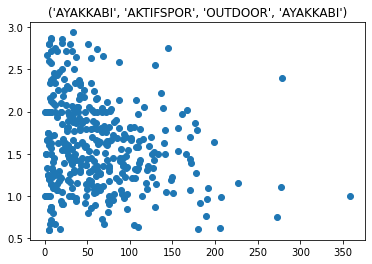

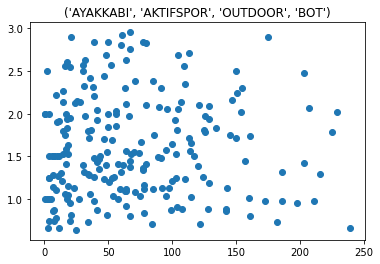

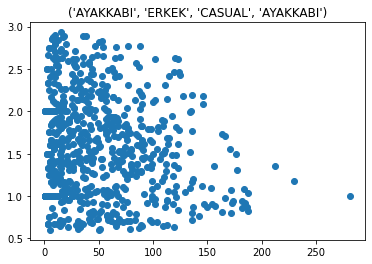

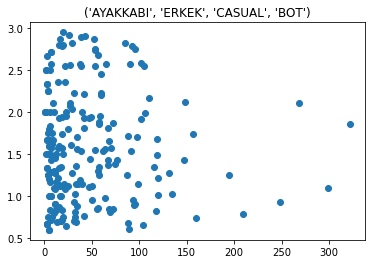

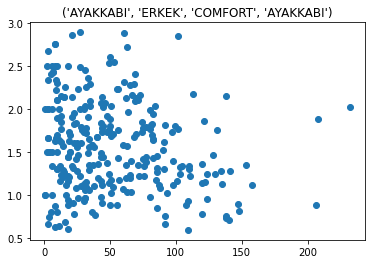

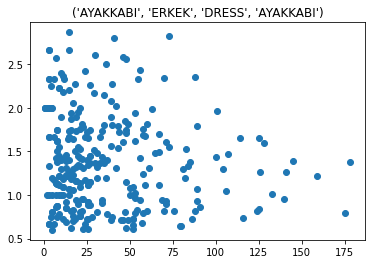

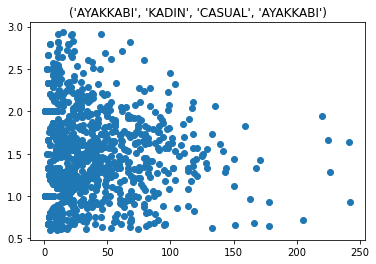

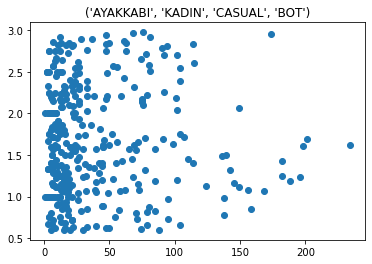

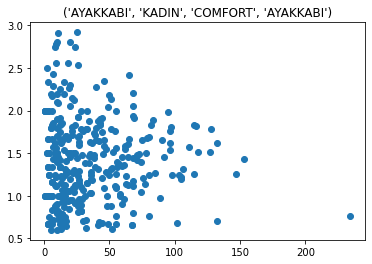

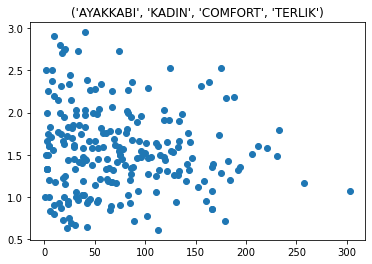

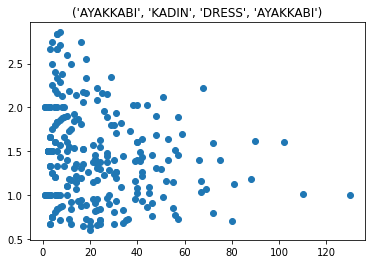

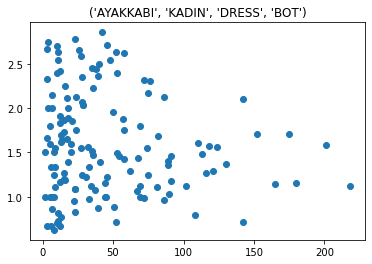

In [176]:
for key, values in data3.groupby(["H1","H2","H3","H4"]):
    if len(values)<100:
        continue
    plt.scatter(values["PrevSales"],values["Fraction"])
    plt.title(key)
    plt.show()

In [177]:
data3[["Sales","PrevSales"]].corr()

,Sales,PrevSales
Sales,1.000000,0.885866
PrevSales,0.885866,1.000000


In [178]:
data3[["Sales","Stock"]].corr()

,Sales,Stock
Sales,1.000000,0.755296
Stock,0.755296,1.000000


In [179]:
import seaborn as sns

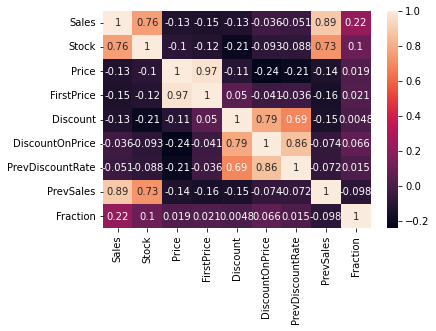

In [180]:
sns.heatmap(data3.corr(),annot=True)
plt.show()

In [181]:
data3.dtypes

H1                   object
H2                   object
H3                   object
H4                   object
H5                   object
ItemCode             object
WeekStartDate        object
Sales                 int64
Stock                 int64
Price               float64
FirstPrice          float64
Discount            float64
DiscountOnPrice     float64
PrevDiscountRate    float64
PrevSales             int64
Fraction            float64
dtype: object

c:\Users\yasin.secal\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


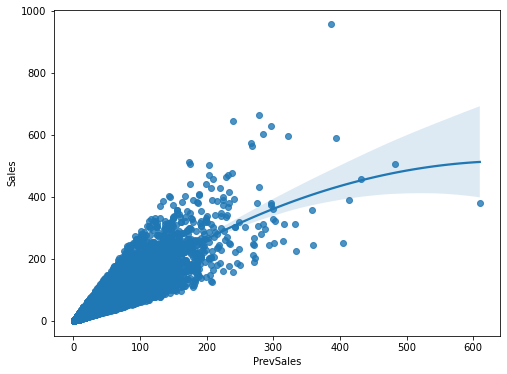

In [182]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
scatter = sns.regplot(data3['PrevSales'], data3['Sales'], order=2)
plt.show()

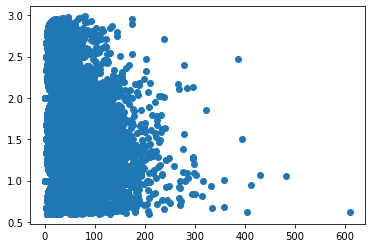

In [183]:
plt.scatter(data3.PrevSales,data3.Fraction)
plt.show()

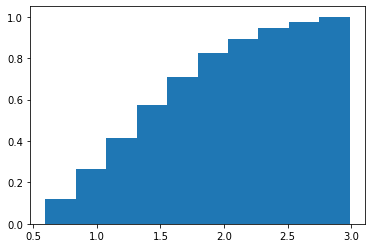

In [184]:
plt.hist(data3.Fraction,density=True,cumulative=1)
plt.show()

In [186]:
from sklearn.model_selection import train_test_split

In [187]:
features = ["PrevSales","Stock","DiscountOnPrice","PrevDiscountRate","H5"]

In [245]:
X = data3[features]
#X["H5"] = X["H5"].astype("category")
y = data3["Sales"]

In [247]:
y

2        15
3        48
4         8
5         7
6        13
         ..
13902    39
13903     5
13905    23
13906    59
13907    14
Name: Sales, Length: 10167, dtype: int64

In [196]:
trainX,testX,trainY, testY = train_test_split(X,y,train_size=round(len(data3)*0.75))

In [199]:
trainY

5313     239
4770       7
13523     40
7055      70
9553      45
        ... 
1969      14
11165     34
12939     80
1244      78
5760     112
Name: Sales, Length: 7625, dtype: int64

In [69]:
from sklearn.linear_model import LinearRegression

In [90]:
import xgboost as xgb

In [297]:

params = {
            "objective": "reg:squarederror",
            "learning_rate": 0.05,
            "n_estimators": 100,
            "max_depth": 6,
            "booster": "gbtree",
            "min_child_weight": 4,
            "subsample": 1,
            "colsample_bytree": 0.85,
            "grow_policy": "lossguide",
            "eval_metric": "mae",
            "importance_type": "weight",
            "verbosity": 2,
            "n_jobs": 1,
            "enable_categorical": True
          }


In [298]:
model = xgb.train(params,dtrain)
pred = model.predict(dtest)
mean_absolute_percentage_error(testY,pred)

[11:23:33] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "enable_categorical", "importance_type", "n_estimators" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[11:23:33] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 102 extra nodes, 0 pruned nodes, max_depth=6
[11:23:33] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 104 extra nodes, 0 pruned nodes, max_depth=6
[11:23:33] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 104 extra nodes, 0 pruned nodes, max_depth=6
[11:23:33] INFO: C:/Users/Administrator/workspace/x


[11:23:33] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 104 extra nodes, 0 pruned nodes, max_depth=6
[11:23:33] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 110 extra nodes, 0 pruned nodes, max_depth=6
[11:23:33] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 102 extra nodes, 0 pruned nodes, max_depth=6
[11:23:33] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 112 extra nodes, 0 pruned nodes, max_depth=6
[11:23:33] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 108 extra nodes, 0 pruned nodes, max_depth=6
[11:23:33] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 102 extra no

0.5200909735673186

In [72]:
params["monotone_constraints"] = (0,0,-1,1,0)

In [204]:
model = xgb.XGBRegressor(**params)

In [205]:
model.fit(trainX,trainY)

c:\Users\yasin.secal\Anaconda3\lib\site-packages\xgboost\data.py:208: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


ValueError: DataFrame.dtypes for data must be int, float, bool or categorical.  When
                categorical type is supplied, DMatrix parameter
                `enable_categorical` must be set to `True`.H5

In [191]:
print(model)

XGBRegressor(base_score=None, booster='gbtree', colsample_bylevel=None,
             colsample_bynode=None, colsample_bytree=0.85,
             enable_categorical=True, eval_metric='mae', gamma=None,
             gpu_id=None, grow_policy='lossguide', importance_type='weight',
             interaction_constraints=None, learning_rate=0.05,
             max_delta_step=None, max_depth=6, min_child_weight=4, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=1,
             num_parallel_tree=None, random_state=None, reg_alpha=None,
             reg_lambda=None, scale_pos_weight=None, subsample=1,
             tree_method=None, validate_parameters=None, verbosity=2)


In [ ]:
            ''' "n_estimators": [100,200,300],
            "max_depth": [6,8,10],
            "min_child_weight": [4,5,6],
            "subsample": [0.8,0.9,1],
            "colsample_bytree": [0.8,0.9,1],
            "gamma": [0,0.1,0.2],
            "reg_alpha": [0,0.1,0.2],'''

In [129]:
#hyperparameter tuning

from sklearn.model_selection import GridSearchCV

params = {
            "learning_rate": [0.05,0.1,0.2],
            "n_estimators": [100,200,300],
            "max_depth": [6,8,10],
            "min_child_weight": [4,5,6],
          }

In [96]:
params

{'learning_rate': [0.05, 0.1, 0.2],
 ' "n_estimators": [100,200,300],\n            "max_depth": [6,8,10],\n            "min_child_weight": [4,5,6],\n            "subsample": [0.8,0.9,1],\n            "colsample_bytree": [0.8,0.9,1],\n            "gamma": [0,0.1,0.2],\n            "reg_alpha": [0,0.1,0.2],enable_categorical': [True]}

In [192]:
import optuna
from sklearn.metrics import mean_absolute_percentage_error

In [206]:
trainX.dtypes

PrevSales              int64
Stock                  int64
DiscountOnPrice      float64
PrevDiscountRate     float64
H5                  category
dtype: object

In [212]:
trainX

,PrevSales,Stock,DiscountOnPrice,PrevDiscountRate,H5
5544,29,1101,0.258625,0.000000,ATHLETIC
12069,13,295,0.225993,0.000000,MILITARY BOT
2026,8,50,0.341178,0.176472,HAVUZ TABAN SNEAKER
7671,2,56,0.217215,0.000000,OUTDOOR
12396,34,711,0.300008,0.169690,OUTDOOR
...,...,...,...,...,...
11011,78,1863,0.220591,0.000000,KAR CIZMESI
4712,9,175,0.193551,0.000000,INFORMAL BAGCIKLI
11227,83,2220,0.146054,0.000000,BASIC SNEAKER
7038,17,644,0.200006,0.000000,KOSU


In [248]:
trainX, trainY = X,y
trainX = pd.get_dummies(trainX,columns=["H5"])

In [259]:
dtrainx = xgb.DMatrix(trainX, label=trainY)

c:\Users\yasin.secal\Anaconda3\lib\site-packages\xgboost\data.py:208: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


In [261]:
dtrainx.feature_names

['PrevSales',
 'Stock',
 'DiscountOnPrice',
 'PrevDiscountRate',
 'H5_AQUA',
 'H5_ATHLETIC',
 'H5_ATHLETIC BOT',
 'H5_BABET',
 'H5_BASIC GUNLUK AYAKKABI',
 'H5_BASIC GUNLUK BOT',
 'H5_BASIC GUNLUK CIZME',
 'H5_BASIC SNEAKER',
 'H5_BASKETBOL',
 'H5_BIKER BOT',
 'H5_BOOTIE',
 'H5_CASUAL COMFORT',
 'H5_CASUAL COMFORT BOT',
 'H5_CHELSEA BOT',
 'H5_DR. MARTE BOT',
 'H5_DRESS',
 'H5_DRESS COMFORT',
 'H5_DRESS COMFORT BOT',
 'H5_DUZ BOT',
 'H5_DUZ CIZME',
 'H5_EV ICI TERLIK',
 'H5_FASHION BOT',
 'H5_FASHION SNEAKER',
 'H5_FASHION SNEAKER BOT',
 'H5_FORMAL BAGCIKLI',
 'H5_FORMAL BOT',
 'H5_FORMAL CIFT YUZ',
 'H5_FORMAL MAKOSEN',
 'H5_FORMAL MASKARETLI',
 'H5_FUTBOL',
 'H5_GELENEKSEL COMFORT BAGCIKLI',
 'H5_GELENEKSEL COMFORT BOT',
 'H5_GELENEKSEL COMFORT DOLGU',
 'H5_GELENEKSEL COMFORT DOLGU BOT',
 'H5_GELENEKSEL COMFORT DUZ',
 'H5_GELENEKSEL COMFORT DUZ BOT',
 'H5_GELENEKSEL COMFORT MAKOSEN',
 'H5_GELENEKSEL COMFORT OKCELI',
 'H5_GELENEKSEL COMFORT OKCELI BOT',
 'H5_GOVA',
 'H5_HAVUZ TABAN SN

In [281]:
X= pd.get_dummies(X,columns=["H5"])
trainX,testX,trainY, testY = train_test_split(X,y,train_size=round(len(data3)*0.75))

In [282]:
dtrain = xgb.DMatrix(trainX, label=trainY,enable_categorical=True)
dtest = xgb.DMatrix(testX, label=testY,enable_categorical=True)

c:\Users\yasin.secal\Anaconda3\lib\site-packages\xgboost\data.py:208: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


In [288]:
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
        'subsample': trial.suggest_float('subsample', 0.1, 1.0),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.1, 1.0),
        "booster": "gbtree",
        "grow_policy": "lossguide",
        "eval_metric": "mae",
        "importance_type": "weight",
        "enable_categorical": True
    }

    model = xgb.train(params,dtrain)
    y_pred = model.predict(dtest)
    mape = mean_absolute_percentage_error(testY, y_pred)
    return mape


In [289]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200)

print('Number of finished trials: ', len(study.trials))
print('Best trial:')
trial = study.best_trial

print('Value: ', trial.value)
print('Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')


[I 2023-11-29 11:17:17,495] A new study created in memory with name: no-name-43695013-a05d-4096-b61e-4181f2c097dc


[11:17:17] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "enable_categorical", "importance_type", "n_estimators" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[11:17:17] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 286 extra nodes, 0 pruned nodes, max_depth=10
[11:17:17] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 300 extra nodes, 0 pruned nodes, max_depth=10
[11:17:17] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 270 extra nodes, 0 pruned nodes, max_depth=10
[11:17:18] INFO: C:/Users/Administrator/workspac

[I 2023-11-29 11:17:18,382] Trial 0 finished with value: 0.5632501206690628 and parameters: {'colsample_bytree': 0.47751204216509824, 'subsample': 0.7326138195938156, 'learning_rate': 0.2676409400851412, 'max_depth': 10, 'n_estimators': 89, 'min_child_weight': 1}. Best is trial 0 with value: 0.5632501206690628.


[11:17:18] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "enable_categorical", "importance_type", "n_estimators" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[11:17:18] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 54 extra nodes, 0 pruned nodes, max_depth=8
[11:17:18] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 156 extra nodes, 0 pruned nodes, max_depth=8
[11:17:18] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 16 extra nodes, 0 pruned nodes, max_depth=8
[11:17:18] INFO: C:/Users/Administrator/workspace/xgb

[I 2023-11-29 11:17:19,073] Trial 1 finished with value: 1.2475400379083659 and parameters: {'colsample_bytree': 0.17578502377077215, 'subsample': 0.7086857922935954, 'learning_rate': 0.1286814175495983, 'max_depth': 8, 'n_estimators': 300, 'min_child_weight': 7}. Best is trial 0 with value: 0.5632501206690628.


...

[11:20:12] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 500 extra nodes, 0 pruned nodes, max_depth=15
[11:20:13] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "enable_categorical", "importance_type", "n_estimators" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[11:20:13] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 136 extra nodes, 0 pruned nodes, max_depth=9
[11:20:13] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 172 extra nodes, 0 pruned nodes, max_depth=11
[11:20:13] INFO: C:/Users/Administrator/workspace

[I 2023-11-29 11:20:14,387] Trial 198 finished with value: 0.3014189431936938 and parameters: {'colsample_bytree': 0.9823705026237273, 'subsample': 0.530480437776919, 'learning_rate': 0.1954101035026013, 'max_depth': 15, 'n_estimators': 149, 'min_child_weight': 9}. Best is trial 172 with value: 0.29578045723777624.


[11:20:14] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 624 extra nodes, 0 pruned nodes, max_depth=15
[11:20:14] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 524 extra nodes, 0 pruned nodes, max_depth=15
[11:20:14] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "enable_categorical", "importance_type", "n_estimators" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[11:20:14] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 130 extra nodes, 0 pruned nodes, max_depth=10
[11:20:14] INFO: C:/Users/Administrator/workspac

[I 2023-11-29 11:20:16,150] Trial 199 finished with value: 0.3040594114857438 and parameters: {'colsample_bytree': 0.9592719237853651, 'subsample': 0.48517885060841154, 'learning_rate': 0.19996105270005293, 'max_depth': 15, 'n_estimators': 136, 'min_child_weight': 9}. Best is trial 172 with value: 0.29578045723777624.


Number of finished trials:  200
Best trial:
Value:  0.29578045723777624
Params: 
    colsample_bytree: 0.9988052695796391
    subsample: 0.5005243149749486
    learning_rate: 0.18805937496222197
    max_depth: 7
    n_estimators: 92
    min_child_weight: 9


In [290]:
best_params = study.best_params
final_model = xgb.train(best_params, dtrain)

[11:20:47] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "n_estimators" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[11:20:48] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 108 extra nodes, 0 pruned nodes, max_depth=7


[11:20:48] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 122 extra nodes, 0 pruned nodes, max_depth=7
[11:20:48] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 142 extra nodes, 0 pruned nodes, max_depth=7
[11:20:48] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 142 extra nodes, 0 pruned nodes, max_depth=7
[11:20:48] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 166 extra nodes, 0 pruned nodes, max_depth=7
[11:20:48] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 142 extra nodes, 0 pruned nodes, max_depth=7
[11:20:48] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/tree/updater_prune.cc:101: tree pruning end, 152 extra nod

In [291]:
best_params

{'colsample_bytree': 0.9988052695796391,
 'subsample': 0.5005243149749486,
 'learning_rate': 0.18805937496222197,
 'max_depth': 7,
 'n_estimators': 92,
 'min_child_weight': 9}

In [292]:
pred = final_model.predict(dtest)
mean_absolute_percentage_error(testY, pred)

0.29578045723777624

In [130]:
def_params={        
            "booster": "gbtree",
            "grow_policy": "lossguide",
            "eval_metric": "mae",
            "importance_type": "weight",
            "verbosity": 2,
            "n_jobs": 1,
            "enable_categorical": True
            }

In [131]:
trainX,trainY = X,y
trainX= pd.get_dummies(trainX, columns = ["H5"])

In [123]:
trainX.dtypes

PrevSales              int64
Stock                  int64
DiscountOnPrice      float64
PrevDiscountRate     float64
H5_AQUA                uint8
                      ...   
H5_TRAINING            uint8
H5_WESTERN BOT         uint8
H5_WORKER BOT          uint8
H5_YAGMUR BOTU         uint8
H5_YAGMUR CIZMESI      uint8
Length: 76, dtype: object

In [132]:
model = xgb.XGBRegressor(**def_params)

In [133]:
model

XGBRegressor(base_score=None, booster='gbtree', colsample_bylevel=None,
             colsample_bynode=None, colsample_bytree=None,
             enable_categorical=True, eval_metric='mae', gamma=None,
             gpu_id=None, grow_policy='lossguide', importance_type='weight',
             interaction_constraints=None, learning_rate=None,
             max_delta_step=None, max_depth=None, min_child_weight=None,
             missing=nan, monotone_constraints=None, n_estimators=100, n_jobs=1,
             num_parallel_tree=None, random_state=None, reg_alpha=None,
             reg_lambda=None, scale_pos_weight=None, subsample=None,
             tree_method=None, validate_parameters=None, verbosity=2)

In [134]:
trainX

,PrevSales,Stock,DiscountOnPrice,PrevDiscountRate,H5_AQUA,H5_ATHLETIC,H5_ATHLETIC BOT,H5_BABET,H5_BASIC GUNLUK AYAKKABI,H5_BASIC GUNLUK BOT,...,H5_SNEAKER,H5_SNEAKER BOT,H5_SNEAKER HI,H5_SPORT COMFORT,H5_TENIS,H5_TRAINING,H5_WESTERN BOT,H5_WORKER BOT,H5_YAGMUR BOTU,H5_YAGMUR CIZMESI
2,11,1108,0.214289,0.000000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,20,1040,0.357148,0.214289,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,4,379,0.200002,0.000000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,11,927,0.147061,0.000000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,18,862,0.294122,0.147061,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13902,40,1529,0.194867,0.000000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13903,2,18,0.125156,0.000000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13905,18,759,0.166669,0.000000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13906,46,1666,0.101946,0.000000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [135]:
grid = GridSearchCV(model,param_grid=params,cv=5,verbose=2,n_jobs=-1)

grid.fit(trainX,trainY)


Fitting 5 folds for each of 81 candidates, totalling 405 fits


KeyboardInterrupt: 

In [128]:
#get best parameters
grid.best_params_


{'learning_rate': 0.05}

In [240]:
modeldict = {}
pred = []
actual = []
for key, item in data3.groupby(["H1","H2","H3","H4"]):
    X = data3[features]
    X["H5"] = X["H5"].astype("category")
    y = data3["Sales"]
    trainX,testX,trainY, testY = train_test_split(X,y,train_size=round(len(X)*0.75))
    if len(trainX)<20:
        continue
    model = xgb.XGBRegressor(**params)
    model.fit(trainX,trainY)
    modeldict[key] = model
    pred.append(np.round(model.predict(testX)))
    actual.append(testY)
    



C:\Users\yasin.secal\AppData\Local\Temp\ipykernel_22484\2123219384.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["H5"] = X["H5"].astype("category")
c:\Users\yasin.secal\Anaconda3\lib\site-packages\xgboost\data.py:208: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


ValueError: DataFrame.dtypes for data must be int, float, bool or categorical.  When
                categorical type is supplied, DMatrix parameter
                `enable_categorical` must be set to `True`.H5

In [100]:
pred = np.concatenate(pred)

In [102]:
b = pd.DataFrame({"pred":pred,"actual":np.concatenate(actual)})

In [103]:
np.sum(np.abs((b["actual"] - b["pred"])) / np.sum(b["actual"])) 

0.2579846750421844

In [104]:
np.sum(((b["actual"] - b["pred"])) / np.sum(b["actual"])) 

0.002154680717391758

In [176]:
result = pd.merge(a,data3,left_index=True,right_index=True,how="inner")

In [177]:
result

,Actual,Pred,H1,H2,H3,H4,H5,ItemCode,WeekStartDate,Sales,Stock,Price,FirstPrice,Discount,DiscountOnPrice,PrevDiscountRate,PrevSales,Fraction
4719,6,10.0,AYAKKABI,KADIN,COMFORT,AYAKKABI,BOOTIE,000000000101187633,2023-09-21,6,388,648.1389,787.0278,0.191400,0.176473,0.000000,4,1.500000
10540,163,201.0,AYAKKABI,AKTIFCOCUK,OUTDOOR,BOT,OUTDOOR HI,000000000101166964,2023-01-19,163,2170,219.9900,419.9900,0.486470,0.476202,0.281120,137,1.189781
10203,33,28.0,AYAKKABI,AKTIFCOCUK,LEISURE,BOT,SNEAKER HI,000000000101169845,2023-01-19,33,279,279.9900,499.9900,0.459542,0.440009,0.235109,19,1.736842
5775,10,20.0,AYAKKABI,COCUK,NaN,BOT,SNEAKER HI,000000000101336568,2023-11-23,10,268,370.3611,462.9537,0.214500,0.200004,0.000000,16,0.625000
1823,119,187.0,AYAKKABI,COCUK,NaN,AYAKKABI,ATHLETIC,000000000101450599,2023-10-26,119,2330,212.9537,305.5463,0.352700,0.303040,0.151520,139,0.856115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5320,6,8.0,AYAKKABI,AKTIFSPOR,LEISURE,AYAKKABI,SNEAKER,000000000101424167,2023-10-05,6,260,1666.6574,2037.0278,0.357400,0.181819,0.000000,4,1.500000
5680,2,6.0,AYAKKABI,COCUK,NaN,BOT,SNEAKER HI,000000000101065781,2023-11-09,2,214,398.1389,490.7315,0.599000,0.188683,0.000000,3,0.666667
4430,17,22.0,AYAKKABI,AKTIFCOCUK,OUTDOOR,AYAKKABI,OUTDOOR,000000000101392008,2023-10-05,17,650,787.0278,925.9167,0.187600,0.150002,0.000000,13,1.307692
5744,52,36.0,AYAKKABI,AKTIFSPOR,ATHLETIC,AYAKKABI,SPORT COMFORT,000000000101350959,2023-10-26,52,386,305.5463,370.3611,0.331100,0.175004,0.000000,29,1.793103


In [179]:
result["abs_error"] = abs(result.Pred-result.Actual)

In [180]:
price_elasticity = pd.DataFrame(columns=["H1","H2","H3","H4","price_elasticity"])

In [186]:
header=[]
Sales =[]
ActualSales =[]
PrevSales =[]
MdLoss =[]
PrevMdLoss =[]
ItemCount=[]
MAPE = []

In [187]:
for indicies, values in result.groupby(by=["H1","H2","H3","H4"]):
    header.append(indicies)
    Sales.append(np.sum(values.Pred))
    ActualSales.append(np.sum(values.Sales))
    PrevSales.append(np.sum(values.PrevSales))
    MdLoss.append(1-(np.sum(values.Sales*values.Price)/np.sum(values.Sales*values.FirstPrice)))
    PrevMdLoss.append(1-(np.sum((1-values.PrevDiscountRate)*values.FirstPrice*values.PrevSales)/np.sum(values.PrevSales*values.FirstPrice)))
    ItemCount.append(values["H1"].count())
    MAPE.append(np.sum(values.abs_error)/np.sum(values.Sales))

    

In [188]:
elasticity = np.log(np.array(Sales)/np.array(PrevSales))/np.log(1-(np.array(MdLoss)-np.array(PrevMdLoss)))

In [189]:
pd.DataFrame(data={
    "hierarchy":header,
    "price_elasticity": elasticity,
    "item_count":ItemCount,
    "sales":Sales,
    "prev_sales":PrevSales,
    "actual_sales":ActualSales,
    "MAPE":MAPE
}).sort_values("price_elasticity",ignore_index=True)

,hierarchy,price_elasticity,item_count,sales,prev_sales,actual_sales,MAPE
0,"(AYAKKABI, AKTIFSPOR, OUTDOOR, SANDALET)",-3.811268,1,18.0,11,19,0.052632
1,"(AYAKKABI, AKTIFSPOR, OUTDOOR, KURKLU BOT)",-2.486597,1,14.0,9,24,0.416667
2,"(AYAKKABI, KADIN, DRESS, CIZME)",-2.448809,2,68.0,44,76,0.210526
3,"(AYAKKABI, AKTIFSPOR, LEISURE, KURKLU AYAKKABI)",-2.420424,3,93.0,46,78,0.192308
4,"(AYAKKABI, ERKEK, DRESS, BOT)",-2.376815,15,751.0,499,739,0.370771
5,"(AYAKKABI, KADIN, DRESS, AYAKKABI)",-2.257756,57,1844.0,1145,1511,0.407015
6,"(AYAKKABI, KADIN, COMFORT, AYAKKABI)",-2.229876,86,3940.0,2610,3677,0.246668
7,"(AYAKKABI, KADIN, CASUAL, AYAKKABI)",-2.160490,236,14272.0,9172,13297,0.250808
8,"(AYAKKABI, KADIN, CASUAL, BOT)",-2.159311,85,5003.0,3240,5862,0.346469
9,"(AYAKKABI, KADIN, DRESS, BOT)",-1.993152,37,2482.0,1651,2510,0.232669


In [109]:
trainX

,PrevSales,Stock,Price,DiscountOnPrice,PrevDiscountRate
2341,93,1360,537.0278,0.147061,0.000000
1156,53,585,462.9537,0.264710,0.000000
4606,6,156,611.1019,0.204822,0.000000
5030,21,663,129.9900,0.350018,0.000000
2759,2,141,351.8426,0.309097,0.000000
...,...,...,...,...,...
4412,75,1700,462.9537,0.166669,0.000000
3090,10,358,399.9900,0.200004,0.000000
6845,53,1980,289.9900,0.420008,0.275368
6348,3,179,999.9900,0.254490,0.000000
